# Local LLM Evaluation: Qwen2.5 (GGUF) on Indonesian Tasks

This notebook runs two experiments on small open-weight models, self-hosted with `llama-cpp-python` (no external API):

1. **Benchmark**: 30 Indonesian-language questions (easy / medium / hard), Qwen2.5-1.5B vs 3B, both 8-bit quantized.
2. **Structured extraction**: turning noisy OCR text from technical drawings / BOMs into JSON, comparing *prompt-only* decoding with *schema-constrained* decoding.

Helper code lives in `src/llm_eval.py` (unit-tested, see `tests/`). Raw outputs and summary tables are written to `results/`.

> **Recommended runtime:** GPU (e.g. Colab T4). On CPU the run works but takes much longer. The environment (GPU, library version, whether GPU offload is active) is saved to `results/environment.json`.

## 0. Setup

In [1]:
import os
import shutil
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/arielshakaramiro/local-llm-eval.git"  # adjust if your repo name differs


def find_root():
    here = Path.cwd().resolve()
    for p in (here, here.parent):
        if (p / "src" / "llm_eval.py").exists():
            return p
    return None


ROOT = find_root()
if ROOT is None:  # fresh Colab runtime: clone the repository
    result = subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "local-llm-eval"],
                             capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            "Could not find the project locally, and 'git clone' failed "
            f"(exit code {result.returncode}). This usually means the repository has not "
            f"been pushed to {REPO_URL} yet, or REPO_URL above needs updating.\n\n"
            "Quick fix for this session: upload local-llm-eval.zip via the Colab file "
            "browser (folder icon on the left), then run:\n"
            "  import zipfile; zipfile.ZipFile('local-llm-eval.zip').extractall('.')\n"
            "and re-run this cell.\n\n"
            f"git error output:\n{result.stderr}"
        )
    ROOT = Path("local-llm-eval").resolve()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: /content/local-llm-eval


If an NVIDIA GPU is present, `llama-cpp-python` must be **built with CUDA**; a plain `pip install` gives a CPU-only build even on a GPU runtime. The cell below removes any earlier build and bypasses pip's cache, otherwise a cached CPU-only wheel would be reused. **The build takes roughly 5–10 minutes.**

If you change the build after `llama_cpp` was already imported in this session, restart the runtime (`Runtime → Restart session`) and re-run from the top.

In [2]:
HAS_NVIDIA = shutil.which("nvidia-smi") is not None

flags = ["--no-cache-dir"] if HAS_NVIDIA else []
cmd = [sys.executable, "-m", "pip", "install", "-q", *flags, "-r", "requirements.txt"]
env = dict(os.environ)

if HAS_NVIDIA:
    env["CMAKE_ARGS"] = "-DGGML_CUDA=on"
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "llama-cpp-python"], check=False)
    print("NVIDIA GPU found: building llama-cpp-python with CUDA (about 5-10 minutes)...")

subprocess.run(cmd, check=True, env=env)
print("Install finished.")

NVIDIA GPU found: building llama-cpp-python with CUDA (about 5-10 minutes)...
Install finished.


In [3]:
import json

import matplotlib.pyplot as plt
import pandas as pd

import llm_eval as le

# display name -> (Hugging Face repo, GGUF file)
MODELS = {
    "Qwen2.5-1.5B Q8": ("Qwen/Qwen2.5-1.5B-Instruct-GGUF", "qwen2.5-1.5b-instruct-q8_0.gguf"),
    "Qwen2.5-3B Q8":   ("Qwen/Qwen2.5-3B-Instruct-GGUF",   "qwen2.5-3b-instruct-q8_0.gguf"),
}

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 200)

### Environment

Saved next to the results so every number can be tied to the hardware it came from. If an NVIDIA GPU is present but `gpu_offload_supported` is `False`, inference is silently running on the CPU.

In [4]:
env_info = le.describe_environment()
(RESULTS / "environment.json").write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print(json.dumps(env_info, indent=2))

if le.detect_gpu() and env_info["gpu_offload_supported"] is False:
    print("\nWARNING: an NVIDIA GPU is present, but llama-cpp-python was built without GPU support, "
          "so inference will run on the CPU. Restart the runtime (Runtime > Restart session) "
          "and re-run the install cell before continuing.")

ggml_cuda_init: found 1 CUDA devices (Total VRAM: 40441 MiB):
  Device 0: NVIDIA A100-SXM4-40GB, compute capability 8.0, VMM: yes, VRAM: 40441 MiB


{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "gpu": "NVIDIA A100-SXM4-40GB, 40960 MiB",
  "llama_cpp_python": "0.3.35",
  "gpu_offload_supported": true,
  "n_gpu_layers": -1
}


## 1. Benchmark

**Design**

- 30 questions, 10 per difficulty level. Questions are in Indonesian on purpose: the goal is to see how small models cope outside English.
- Each question is graded with regex patterns (`must` = groups that all need a hit, `forbid` = patterns that must not appear). This accepts correct answers written as full sentences, which exact-match grading rejects.
- The dataset is self-checking: every question ships an example correct and wrong answer, verified in `tests/`.
- Greedy decoding (`temperature=0`), chat template applied, `n_ctx=4096`, one warm-up call per model, each model loaded once.
- With only 30 questions, accuracy comes with a 95% **Wilson interval**, and the two models are compared on the *same* questions with an exact McNemar test.

In [5]:
questions = le.load_json("data/questions_id.json")
print(len(questions), "questions:", pd.Series([q["level"] for q in questions]).value_counts().to_dict())

30 questions: {'easy': 10, 'medium': 10, 'hard': 10}


In [6]:
results = le.run_benchmark(MODELS, questions)
results.to_csv(RESULTS / "benchmark_results.csv", index=False)


=== Qwen2.5-1.5B Q8 ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


qwen2.5-1.5b-instruct-q8_0.gguf: reconstructing file:   0%|          |  0.00B / 1.89GB            

qwen2.5-1.5b-instruct-q8_0.gguf: downloading bytes:           |  0.00B            

  [q01] ok    0.1s  Berapakah hasil dari 5 ditambah 3?
  [q02] ok    0.1s  Apa ibu kota Prancis?
  [q03] ok    0.1s  Berapa hasil 12 dikali 4?
  [q04] ok    0.1s  Jika ada 10 apel dan Anda mengambil 3, berapa apel y
  [q05] MISS   0.1s  Planet apa yang paling dekat dengan Matahari?
  [q06] ok    0.1s  Berapa jumlah hari dalam seminggu?
  [q07] ok    0.1s  Apa rumus kimia untuk air?
  [q08] ok    0.1s  Berapa hasil dari 100 dibagi 4?
  [q09] ok    0.1s  Siapa presiden pertama Indonesia?
  [q10] ok    0.2s  Bahasa pemrograman apa yang file-nya berekstensi .py
  [q11] MISS   0.3s  Apa itu algoritma Merge Sort? Jelaskan secara singka
  [q12] MISS   0.4s  Apa hukum kedua Newton? Jelaskan secara singkat.
  [q13] MISS   0.5s  Apa itu fotosintesis? Jelaskan secara singkat.
  [q14] ok    0.3s  Apa itu API? Jelaskan secara singkat.
  [q15] MISS   0.9s  Apa perbedaan RAM dan penyimpanan (storage)? Jelaska
  [q16] MISS   0.3s  Apa itu inflasi dalam ekonomi? Jelaskan secara singk
  [q17] MISS   0.1

qwen2.5-3b-instruct-q8_0.gguf: reconstructing file:   0%|          |  0.00B / 3.62GB            

qwen2.5-3b-instruct-q8_0.gguf: downloading bytes:           |  0.00B            

  [q01] ok    0.1s  Berapakah hasil dari 5 ditambah 3?
  [q02] ok    0.1s  Apa ibu kota Prancis?
  [q03] ok    0.1s  Berapa hasil 12 dikali 4?
  [q04] ok    0.1s  Jika ada 10 apel dan Anda mengambil 3, berapa apel y
  [q05] ok    0.1s  Planet apa yang paling dekat dengan Matahari?
  [q06] ok    0.1s  Berapa jumlah hari dalam seminggu?
  [q07] ok    0.1s  Apa rumus kimia untuk air?
  [q08] ok    0.1s  Berapa hasil dari 100 dibagi 4?
  [q09] ok    0.1s  Siapa presiden pertama Indonesia?
  [q10] ok    0.1s  Bahasa pemrograman apa yang file-nya berekstensi .py
  [q11] ok    0.3s  Apa itu algoritma Merge Sort? Jelaskan secara singka
  [q12] ok    0.5s  Apa hukum kedua Newton? Jelaskan secara singkat.
  [q13] MISS   0.3s  Apa itu fotosintesis? Jelaskan secara singkat.
  [q14] ok    0.3s  Apa itu API? Jelaskan secara singkat.
  [q15] ok    0.4s  Apa perbedaan RAM dan penyimpanan (storage)? Jelaska
  [q16] MISS   0.3s  Apa itu inflasi dalam ekonomi? Jelaskan secara singk
  [q17] ok    0.2s  Ap

### Results

In [7]:
summary = le.summarize(results)
summary.to_csv(RESULTS / "benchmark_summary.csv")
(RESULTS / "benchmark_summary.md").write_text(summary.reset_index().to_markdown(index=False), encoding="utf-8")
display(summary)

by_level = le.accuracy_by_level(results)
by_level.to_csv(RESULTS / "benchmark_by_level.csv")
print("Accuracy by difficulty level (%):")
display(by_level)

names = list(MODELS)
if len(names) == 2:
    pc = le.paired_comparison(results, names[0], names[1])
    print(f"Only {names[0]} correct: {pc['only_a_correct']} | only {names[1]} correct: {pc['only_b_correct']} "
          f"| both: {pc['both_correct']} | neither: {pc['both_wrong']}")
    print(f"Exact McNemar p-value: {pc['p_value']:.3f}")

,n,correct,accuracy_pct,ci95_low_pct,ci95_high_pct,mean_latency_s,mean_tokens_per_s,truncated
model,,,,,,,,
Qwen2.5-1.5B Q8,30,20,66.7,48.8,80.8,0.2,214.0,0
Qwen2.5-3B Q8,30,24,80.0,62.7,90.5,0.2,152.7,0


Accuracy by difficulty level (%):


model,Qwen2.5-1.5B Q8,Qwen2.5-3B Q8
level,,
easy,90.0,100.0
medium,30.0,60.0
hard,80.0,80.0


Only Qwen2.5-1.5B Q8 correct: 2 | only Qwen2.5-3B Q8 correct: 6 | both: 18 | neither: 4
Exact McNemar p-value: 0.289


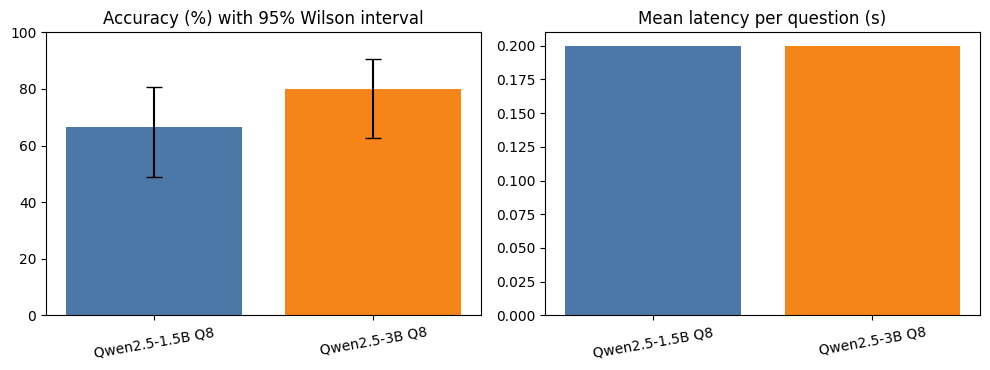

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

lo = summary["accuracy_pct"] - summary["ci95_low_pct"]
hi = summary["ci95_high_pct"] - summary["accuracy_pct"]
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"][: len(summary)]

ax[0].bar(summary.index, summary["accuracy_pct"], yerr=[lo, hi], capsize=6, color=colors)
ax[0].set_ylim(0, 100)
ax[0].set_title("Accuracy (%) with 95% Wilson interval")

ax[1].bar(summary.index, summary["mean_latency_s"], color=colors)
ax[1].set_title("Mean latency per question (s)")

for a in ax:
    a.tick_params(axis="x", rotation=10)
plt.tight_layout()
fig.savefig(RESULTS / "benchmark_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

### Error analysis

Automatic grading can be wrong in both directions. Read the answers marked incorrect before drawing conclusions. If an answer is actually right, widen the patterns in `data/questions_id.json` and re-run.

In [9]:
failed = results.loc[~results["correct"], ["model", "id", "level", "prompt", "answer"]]
print(f"{len(failed)} answers graded wrong | truncated answers: {int(results['truncated'].sum())}")
display(failed)

16 answers graded wrong | truncated answers: 0


,model,id,level,prompt,answer
4,Qwen2.5-1.5B Q8,q05,easy,Planet apa yang paling dekat dengan Matahari?,"Planet yang paling dekat dengan Matahari adalah Bumi, yang kita kenal sebagai planet terdekat atau Perihelion."
10,Qwen2.5-1.5B Q8,q11,medium,Apa itu algoritma Merge Sort? Jelaskan secara singkat.,"Merge Sort adalah algoritma sorting yang menggunakan metode rekursif. Ini membagi array menjadi dua bagian, menganalisis kedua bagian, dan kemudian menggabungkannya kembali. Merge Sort adalah algo..."
11,Qwen2.5-1.5B Q8,q12,medium,Apa hukum kedua Newton? Jelaskan secara singkat.,"Hukum kedua Newton, yang juga dikenal sebagai hukum gaya-tarik, menyatakan bahwa gaya yang diterima oleh benda atau bahan adalah sebesar dan searah dengan gaya yang menyebabkannya bergerak. Ini be..."
12,Qwen2.5-1.5B Q8,q13,medium,Apa itu fotosintesis? Jelaskan secara singkat.,Fotosintesis adalah proses biologis di mana hewan atau tumbuhan mengubah sinar matahari menjadi energi yang dapat digunakan untuk pertumbuhan dan perkembangan. Proses ini melibatkan dua tahap utam...
14,Qwen2.5-1.5B Q8,q15,medium,Apa perbedaan RAM dan penyimpanan (storage)? Jelaskan secara singkat.,RAM (Random Access Memory) dan penyimpanan (storage) adalah dua jenis penyimpanan data yang berbeda dalam komputer. \n\nRAM adalah tempat yang cepat untuk menyimpan data saat komputer sedang berop...
15,Qwen2.5-1.5B Q8,q16,medium,Apa itu inflasi dalam ekonomi? Jelaskan secara singkat.,"Inflasi adalah peningkatan harga barang dan jasa dalam jangka pendek. Ini berarti bahwa harga semakin tinggi, meskipun produksi dan penerimaan uang tetap sama. Inflasi sering disebabkan oleh penin..."
16,Qwen2.5-1.5B Q8,q17,medium,Apa fungsi mitokondria dalam sel?,Fungsi mitokondria dalam sel adalah sebagai tempat untuk melakukan fotosintesis dan pembakaran gula.
18,Qwen2.5-1.5B Q8,q19,medium,Sebutkan tiga wujud zat beserta contohnya.,"Tiga wujud zat beserta contohnya adalah:\n\n1. Zat Susu: Contohnya adalah air, garam, dan asam.\n\n2. Zat Sintesis: Contohnya adalah protein, karbohidrat, dan lemak.\n\n3. Zat Asimilasi: Contohnya..."
24,Qwen2.5-1.5B Q8,q25,hard,"Jika 3 pekerja menyelesaikan sebuah pekerjaan dalam 12 hari, berapa hari yang dibutuhkan 6 pekerja dengan kecepatan kerja yang sama?","Jika 3 pekerja menyelesaikan pekerjaan dalam 12 hari, berarti mereka selesai 1/12 pekerjaan per hari. Jika kita mempunyai 6 pekerja dengan kecepatan kerja yang sama, maka mereka akan selesai 1/6 p..."
27,Qwen2.5-1.5B Q8,q28,hard,"Jika hari ini Rabu, hari apa 10 hari lagi?",Hari 10 hari lagi adalah Minggu.


## 2. Structured extraction

Task: convert OCR text from a drawing or BOM into a fixed JSON structure and flag data-quality anomalies.

Two decoding modes are compared on the same 8 hand-labelled samples (4 clean, 4 with planted anomalies):

- **prompt_only**: the prompt describes the JSON shape; the output is parsed afterwards.
- **schema_constrained**: the same prompt, plus a JSON Schema passed via `response_format`, which restricts which tokens the model can emit.

Metrics: valid JSON rate, strict schema conformance (`schema_ok`, e.g. `quantity` must be an integer), correct part number, correct quantity, and whether anomalies were flagged correctly (a non-empty list only when the record truly has a problem). Outputs that fail to parse score as wrong on everything.

In [10]:
samples = le.load_json("data/ocr_samples.json")
extraction = le.evaluate_extraction(MODELS, samples)
extraction.to_csv(RESULTS / "extraction_results.csv", index=False)


=== Qwen2.5-1.5B Q8 ===
  prompt_only: 8 samples done
  schema_constrained: 8 samples done

=== Qwen2.5-3B Q8 ===
  prompt_only: 8 samples done
  schema_constrained: 8 samples done


In [11]:
ext_summary = le.summarize_extraction(extraction)
ext_summary.to_csv(RESULTS / "extraction_summary.csv")
(RESULTS / "extraction_summary.md").write_text(ext_summary.reset_index().to_markdown(index=False), encoding="utf-8")
display(ext_summary)

parsed  schema_ok  part_no_ok  \
model           mode                                                
Qwen2.5-1.5B Q8 prompt_only          100.0      100.0        87.5   
                schema_constrained   100.0      100.0        87.5   
Qwen2.5-3B Q8   prompt_only          100.0      100.0        87.5   
                schema_constrained   100.0      100.0        87.5   

                                    quantity_ok  anomaly_ok  mean_latency_s  n  
model           mode                                                            
Qwen2.5-1.5B Q8 prompt_only                87.5        62.5             0.4  8  
                schema_constrained         87.5        87.5             3.4  8  
Qwen2.5-3B Q8   prompt_only                87.5       100.0             0.8  8  
                schema_constrained         87.5        62.5             4.9  8

In [12]:
unparsed = extraction.loc[(extraction["mode"] == "prompt_only") & (~extraction["parsed"]),
                          ["model", "sample_id", "raw_output"]]
print(f"{len(unparsed)} prompt_only outputs were not valid JSON")
display(unparsed.head(3))

# One constrained example: sample s5 has a negative quantity, empty fields and an O/0 mix-up
row = extraction[(extraction["sample_id"] == "s5") & (extraction["mode"] == "schema_constrained")].iloc[0]
print(f"\nschema_constrained output, {row['model']}, sample s5:")
try:
    print(json.dumps(json.loads(row["raw_output"]), indent=2, ensure_ascii=False))
except json.JSONDecodeError:
    print(row["raw_output"])

0 prompt_only outputs were not valid JSON


,model,sample_id,raw_output



schema_constrained output, Qwen2.5-1.5B Q8, sample s5:
{
  "components": [
    {
      "part_no": "XYZ-007",
      "description": "Bearing 6204",
      "quantity": -2,
      "material": "",
      "supplier": "",
      "dimensions": "47x20x14 mm"
    }
  ],
  "anomalies": [
    "Quantity: -2",
    "Dimensions: 47x20x14 mm"
  ],
  "summary": "The part number is valid, but the quantity and dimensions are invalid."
}


## 3. Findings

_Write these after the final run, using the tables in `results/`. Suggested structure:_

- **Accuracy vs. size:** how do the two models compare overall and per difficulty level? Do the 95% intervals overlap, and what does the McNemar test say about the paired difference?
- **Cost of accuracy:** latency and tokens/s per model, and hardware used (CPU or GPU model).
- **Constrained decoding:** how do valid-JSON rate and `schema_ok` change with a schema, and what happens to accuracy on quantity and anomaly detection? Guaranteed *structure* is not the same as correct *content*.
- **Failure patterns:** what kinds of questions and samples fail most (multi-step arithmetic, subtle anomalies)?

## 4. Limitations

- 30 questions and 8 extraction samples are small; the intervals above show how wide the uncertainty is.
- Regex grading approximates correctness; it can miss valid phrasings and accept lucky matches.
- One greedy run per model. Timing depends heavily on hardware and load.
- Only Q8 quantization and one model family were tested; Indonesian is the only benchmark language.
- Extraction labels were written by hand; anomalies are planted, not drawn from real production data.

## 5. Next steps

- Grow the question set and add an LLM-as-judge or human review pass for open-ended answers.
- Compare quantization levels (Q4_K_M vs Q8) on accuracy, memory and speed.
- Extend extraction to multi-row BOMs and measure per-field accuracy.